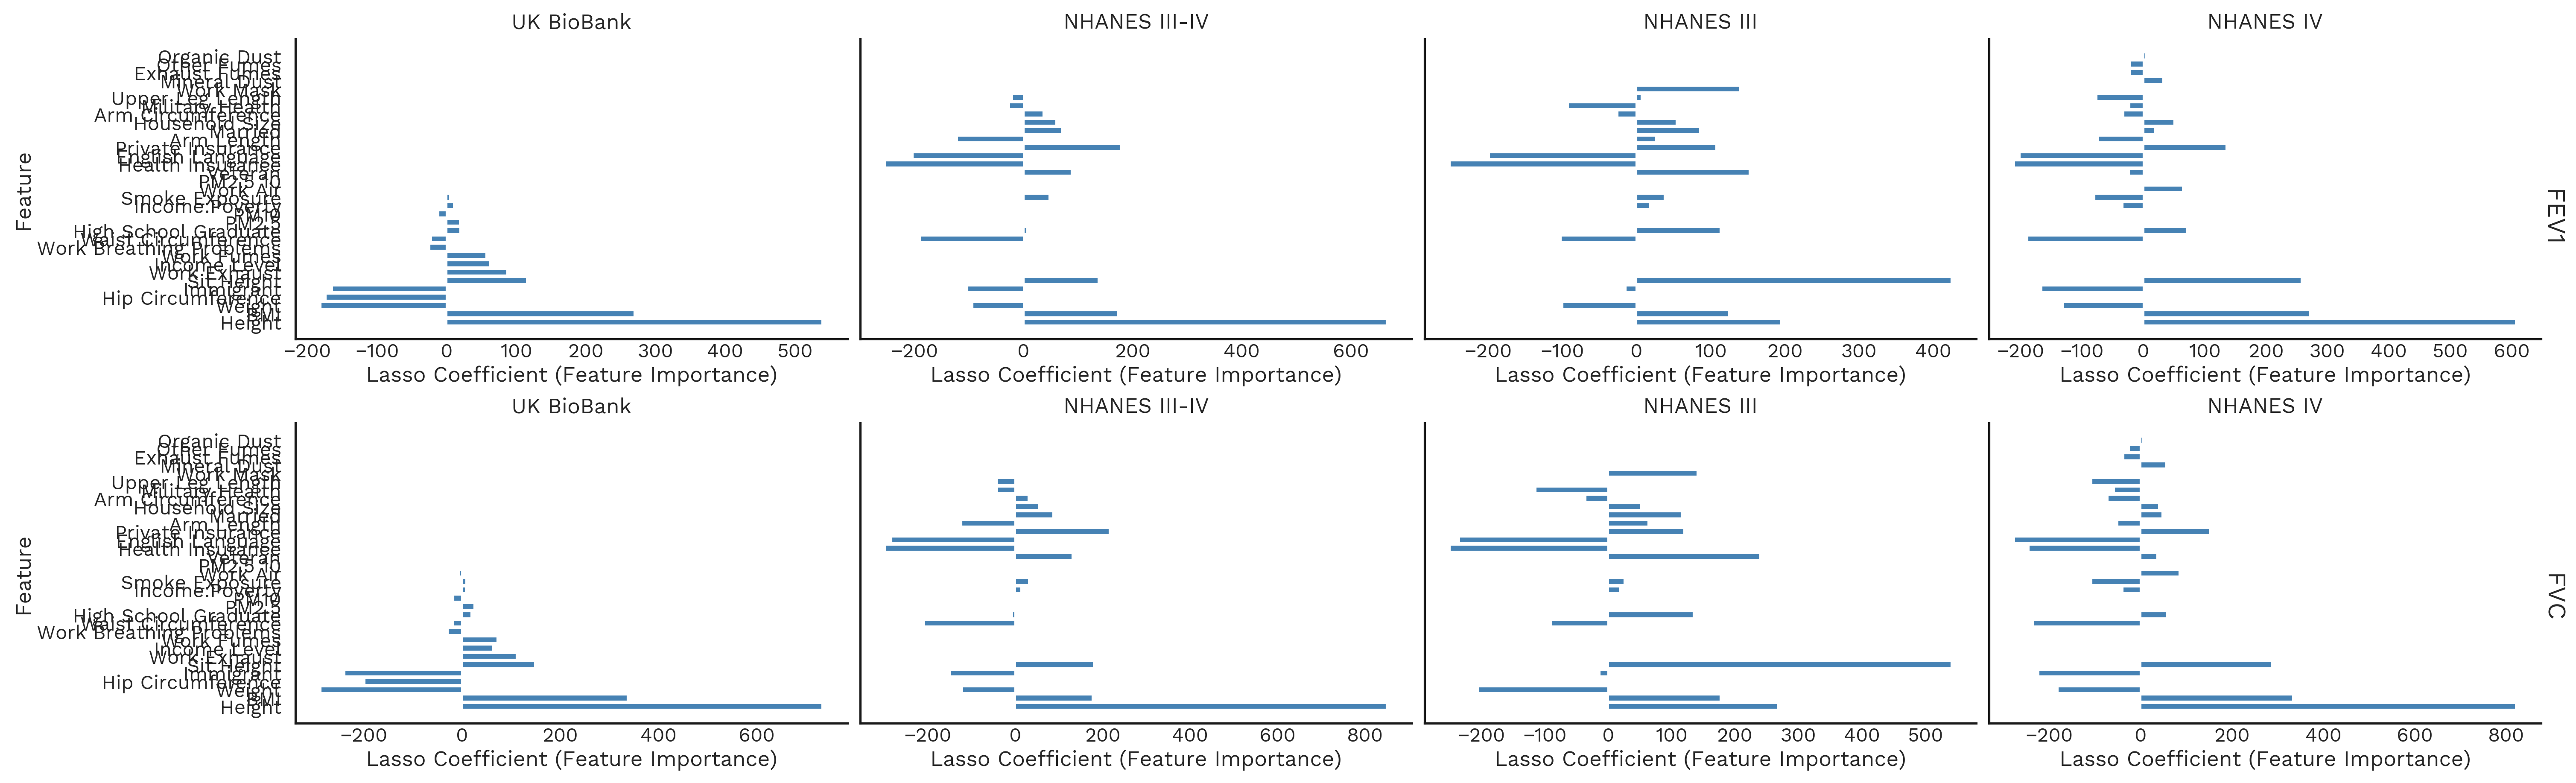

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("../")
from data.dicts.col_dict import int_race_dict, titles_dict # adjust if needed
from helpers.plots import *

data_dir = "../data/processed"
suffix = "ref.csv"
cohorts = ["ukb", "nh", "nh3", "nh4"]
cohort_dict = {
    "ukb": "UK BioBank",
    "nh": "NHANES III-IV",
    "nh3": "NHANES III",
    "nh4": "NHANES IV"
}

results_dir = "../results/lasso"
path_prefix = "feat_imp_"

# Collect feature importance for each (target, cohort) into a MultiIndex DataFrame
cohort_featimps = {}
all_features = set()
all_targets = set()

for c in cohorts:
    fp = f"{results_dir}/{path_prefix}{c}.csv"
    feat_imp = pd.read_csv(fp)
    feat_imp['feature'] = feat_imp['feature'].map(titles_dict)

    if 'target' in feat_imp.columns:
        # Add to set of all targets (includes all seen for all cohorts)
        all_targets.update(feat_imp['target'].unique())
        # For each target in this cohort, collect importance
        for tgt in feat_imp['target'].unique():
            feat_imp_tgt = feat_imp[feat_imp['target'] == tgt].copy()
            # record all features
            all_features.update(feat_imp_tgt['feature'].values)
            feat_imp_tgt = feat_imp_tgt.set_index('feature')['importance']
            cohort_featimps[(tgt, c)] = feat_imp_tgt
    else:
        # If no target column, treat as a single target (use c as the only key)
        all_targets.add('all')
        feat_imp = feat_imp.set_index('feature')['importance']
        all_features.update(feat_imp.index)
        cohort_featimps[('all', c)] = feat_imp

# Sort features and targets for reproducibility
all_features = sorted(all_features)
all_targets = sorted(all_targets)

# Build a DataFrame: index = feature; columns = MultiIndex (target, cohort)
import itertools
multi_index_columns = pd.MultiIndex.from_product(
    [all_targets, cohorts], names=["Target", "Cohort"]
)
feat_imp_table = pd.DataFrame(index=all_features, columns=multi_index_columns, dtype=float)

# Fill the table
for (tgt, c), feat_imp_s in cohort_featimps.items():
    for feat, val in feat_imp_s.items():
        feat_imp_table.loc[feat, (tgt, c)] = val

# Display as table: one row per target, one column per cohort, features as y-axis (rows)
# To visualize: For each target, make a figure with barh for each cohort

num_targets = len(all_targets)
fig, axes = plt.subplots(num_targets, len(cohorts), figsize=(5*len(cohorts), 3*num_targets), sharey=True)

if num_targets == 1:
    axes = axes[np.newaxis, :]  # Ensure 2D shape
if len(cohorts) == 1:
    axes = axes[:, np.newaxis]

for i, tgt in enumerate(all_targets):
    for j, c in enumerate(cohorts):
        ax = axes[i, j]
        col = (tgt, c)
        # Get importances (can be partially NaN if not available)
        imp = feat_imp_table[col].dropna().sort_values(key=np.abs, ascending=False)
        ax.barh(imp.index, imp.values, color='steelblue')
        ax.set_xlabel("Lasso Coefficient (Feature Importance)")
        if j == 0:
            ax.set_ylabel("Feature")
        else:
            ax.set_ylabel("")
        ax.set_title(f"{cohort_dict.get(c, c)}" if tgt == 'all' else f"{cohort_dict.get(c, c)}")
        ax.invert_yaxis()
        # Add rotated (vertical) target label on the right edge of the plot
        # only on the last column
        if j == len(cohorts) - 1:
            ax.text(
                1.02, 0.5, 
                str(tgt).upper(), 
            va='center', ha='left',
            rotation=-90, rotation_mode='anchor',
            transform=ax.transAxes, fontsize=14, fontweight='bold'
        )
plt.tight_layout()
plt.show()